# Single User Resource Allocation Model

This notebook is the reviewer-facing walkthrough of the shared single-user engine. It shows one user,
one distance, and one rate requirement, then exposes the candidate enumeration and feasibility chain
without doing any multi-distance sweep logic.


## 1. Explicit Inputs


In [1]:
import os
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

sys.path.append(str((Path.cwd() / "src").resolve()))

from radio_core import (
    build_pa_catalog,
    build_pa_characteristics_table,
    get_single_user_resource_model_config,
)
from downlink_resource_allocation import SingleUserResourceAllocationEngine


In [2]:
notebook_config = get_single_user_resource_model_config()
link_constants = notebook_config["link_constants"]
phy_constants = notebook_config["phy_constants"]
scheduler_sweep = notebook_config["scheduler_sweep"]
mcs_table = notebook_config["mcs_table"]
PA_DATA_CSV = notebook_config["pa_data_csv"]

user_case = {
    "distance_m": 100.0,
    "rate_target_bps": 80e6,
}

link_constants_table = pd.DataFrame([link_constants])
phy_constants_table = pd.DataFrame([phy_constants])
scheduler_sweep_table = pd.DataFrame(
    [
        {
            "bandwidth_space_hz": str(tuple(float(v) for v in scheduler_sweep["bandwidth_space_hz"])),
            "layers_space": str(list(scheduler_sweep["layers_space"])),
            "mcs_space": f"{min(scheduler_sweep['mcs_space'])}..{max(scheduler_sweep['mcs_space'])}",
            "prb_step": int(scheduler_sweep["prb_step"]),
        }
    ]
)
user_case_table = pd.DataFrame([user_case])

display(link_constants_table)
display(phy_constants_table)
display(scheduler_sweep_table)
display(user_case_table)


,pl_model,fc_hz,g_tx_db,g_rx_db,n0_dbm_per_hz,lna_noise_figure_db,shadow_margin_db
0,umi_sc_nlos,3.500000e+09,8.0,0.0,-174.0,5.0,4.0


,channel_bw_hz,l_impl_db,mi_n_samples,papr_db,g_phi,sigma_phi2,sigma_q2,n_dmrs_sym,n_sym_data,n_sym_total,dft_size_N,t_slot_s,n_tx_chains,use_psd_constraint,psd_max_w_per_hz,delta_f_hz,n_slots_win
0,100000000.0,3.0,1500,8.0,1.0,0.0,0.0,2,12,14,4096,0.0005,4,True,8.000000e-07,30000.0,7


,bandwidth_space_hz,layers_space,mcs_space,prb_step
0,"(100000000.0, 50000000.0)","[1, 2, 4]",0..28,5


,distance_m,rate_target_bps
0,100.0,80000000.0


## 2. Shared Engine


In [3]:
pa_input_table = pd.read_csv(PA_DATA_CSV)
pa_catalog = build_pa_catalog(PA_DATA_CSV)
pa_characteristics = build_pa_characteristics_table(pa_catalog)

engine = SingleUserResourceAllocationEngine(
    link_constants=link_constants,
    phy_constants=phy_constants,
    scheduler_sweep=scheduler_sweep,
    mcs_table=mcs_table,
    pa_catalog=pa_catalog,
)

print(f"PA input rows: {len(pa_input_table):,}")
print(f"PA models in catalog: {len(pa_catalog)}")
display(pa_characteristics)


PA input rows: 34
PA models in catalog: 2


,pa_id,pa_name,source_csv,n_curve_points,p_max_w,p_idle_w,eta_max,g_pa_eff_linear,g_pa_eff_db,kappa_distortion,backoff_db
0,0,Bae et al. NR,PA models\3.5Ghz_pas\4W_8W_NR_combined_NR_carr...,64,7.928899,5.239623,0.418165,1817.545759,32.594854,0.08,6.0
1,1,QPA9942,PA models\3.5Ghz_pas\4W_8W_NR_combined_NR_carr...,64,1.784671,0.641172,0.352236,935.848316,29.712055,0.08,6.0


## 3. Problem Construction


In [4]:
problem = engine.build_single_user_problem(distance_m=user_case["distance_m"])
problem_views = engine.describe_problem(problem)
search_space_summary = pd.DataFrame([engine.estimate_search_space(problem, [user_case])])

display(problem_views["deployment_summary"])
display(problem_views["rrc_catalog"])
display(problem_views["search_space_summary"])
display(search_space_summary)


,distance_m,path_loss_db,fc_hz,n_tx_chains,n_slots_win,delta_f_hz
0,100.0,108.643832,3.500000e+09,4,7,30000.0


,pa_id,bwp_idx,bandwidth_hz,prb_max_bwp,max_layers,max_mcs
0,0,1,50000000.0,138,4,28
1,0,0,100000000.0,277,4,28
2,1,1,50000000.0,138,4,28
3,1,0,100000000.0,277,4,28


,n_slots_on_values,layers_values,n_active_tx_values,mcs_values,prb_step
0,7,3,4,29,5


,pa_count,scenario_count,raw_configs_per_pa_per_scenario,raw_configs_per_scenario,raw_total_configs
0,2,1,136416,272832,272832


## 4. Candidate Enumeration And Evaluation


In [5]:
PUBLIC_CONFIG_COLUMNS = [
    "distance_m",
    "path_loss_db",
    "pa_id",
    "pa_name",
    "rate_ach_bps",
    "p_dc_avg_total_w",
    "layers",
    "mcs",
    "n_prb",
    "n_slots_on",
    "alpha_f",
    "alpha_t",
    "bandwidth_hz",
    "n_active_tx",
    "p_out_total_w",
    "ps_total_w",
    "gamma_req_lin",
]

candidate_preview = pd.DataFrame(
    [candidate.__dict__ for _, candidate in zip(range(10), engine.enumerate_scheduler_candidates(problem))]
)
candidate_table = engine.evaluate_candidate_table(
    problem,
    include_infeasible=True,
    required_rate_bps=user_case["rate_target_bps"],
)
feasible_table = engine.filter_feasible_configurations(
    candidate_table,
    required_rate_bps=user_case["rate_target_bps"],
)

feasibility_summary = (
    candidate_table.groupby(["is_feasible", "infeasibility_reason"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values(["is_feasible", "count"], ascending=[False, False])
    .reset_index(drop=True)
)

best_feasible = feasible_table[PUBLIC_CONFIG_COLUMNS].sort_values(
    ["p_dc_avg_total_w", "bandwidth_hz", "n_prb", "n_slots_on"]
).reset_index(drop=True)

display(candidate_preview)
display(feasibility_summary)
display(best_feasible.head(12))


,pa_id,bwp_idx,n_prb,n_slots_on,layers,n_active_tx,mcs
0,0,0,1,1,1,1,0
1,0,0,1,1,1,1,1
2,0,0,1,1,1,1,2
3,0,0,1,1,1,1,3
4,0,0,1,1,1,1,4
5,0,0,1,1,1,1,5
6,0,0,1,1,1,1,6
7,0,0,1,1,1,1,7
8,0,0,1,1,1,1,8
9,0,0,1,1,1,1,9


,is_feasible,infeasibility_reason,count
0,True,ok,66828
1,False,below_rate_target,205844
2,False,per_chain_pa_cap,160


,distance_m,path_loss_db,pa_id,pa_name,rate_ach_bps,p_dc_avg_total_w,layers,mcs,n_prb,n_slots_on,alpha_f,alpha_t,bandwidth_hz,n_active_tx,p_out_total_w,ps_total_w,gamma_req_lin
0,100.0,108.643832,1,QPA9942,8.292461e+07,2.564688,4,20,26,7,0.188406,1.000000,50000000.0,4,0.113667,0.000121,20.749909
1,100.0,108.643832,1,QPA9942,8.125968e+07,2.564688,4,18,31,7,0.224638,1.000000,50000000.0,4,0.084644,0.000090,12.965105
2,100.0,108.643832,1,QPA9942,9.015197e+07,2.564688,4,19,31,7,0.224638,1.000000,50000000.0,4,0.109321,0.000117,16.743590
3,100.0,108.643832,1,QPA9942,8.088521e+07,2.564688,4,18,36,6,0.260870,0.857143,50000000.0,4,0.098278,0.000105,12.965105
4,100.0,108.643832,1,QPA9942,8.316173e+07,2.564688,4,15,36,7,0.260870,1.000000,50000000.0,4,0.072973,0.000078,9.627467
5,100.0,108.643832,1,QPA9942,8.882957e+07,2.564688,4,16,36,7,0.260870,1.000000,50000000.0,4,0.083782,0.000090,11.053221
6,100.0,108.643832,1,QPA9942,8.869478e+07,2.564688,4,17,36,7,0.260870,1.000000,50000000.0,4,0.079633,0.000085,10.505955
7,100.0,108.643832,1,QPA9942,9.436608e+07,2.564688,4,18,36,7,0.260870,1.000000,50000000.0,4,0.098278,0.000105,12.965105
8,100.0,108.643832,1,QPA9942,8.118169e+07,2.564688,4,15,41,6,0.297101,0.857143,50000000.0,4,0.083096,0.000089,9.627467
9,100.0,108.643832,1,QPA9942,8.671458e+07,2.564688,4,16,41,6,0.297101,0.857143,50000000.0,4,0.095405,0.000102,11.053221


## 5. Compact Feasible-Space Readout


,pa_id,pa_name,feasible_rows,min_rate_bps,max_rate_bps,min_power_w,max_power_w
0,0,Bae et al. NR,33494,80004744.0,1.471773e+09,20.958493,34.558552
1,1,QPA9942,33334,80004744.0,1.412767e+09,2.564688,20.181730


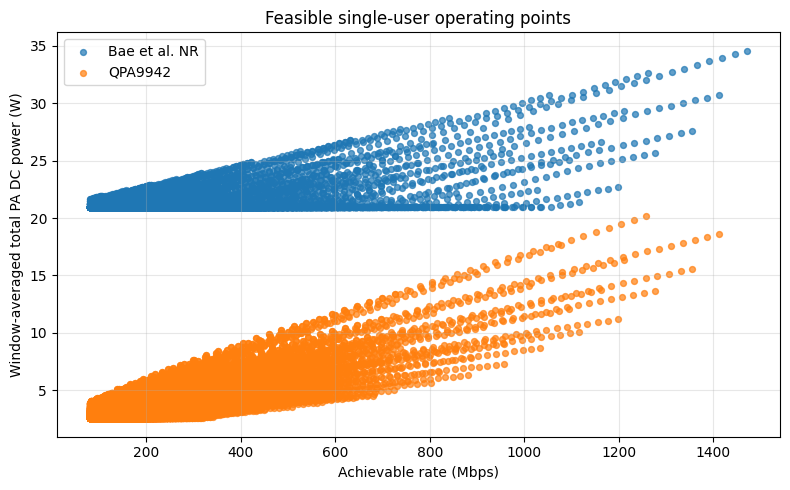

In [6]:
feasible_summary_by_pa = (
    feasible_table.groupby(["pa_id", "pa_name"], dropna=False)
    .agg(
        feasible_rows=("rate_ach_bps", "size"),
        min_rate_bps=("rate_ach_bps", "min"),
        max_rate_bps=("rate_ach_bps", "max"),
        min_power_w=("p_dc_avg_total_w", "min"),
        max_power_w=("p_dc_avg_total_w", "max"),
    )
    .reset_index()
)
display(feasible_summary_by_pa)

fig, ax = plt.subplots(figsize=(8, 5))
for pa_id, df_pa in feasible_table.groupby("pa_id", sort=True):
    ax.scatter(
        df_pa["rate_ach_bps"] / 1e6,
        df_pa["p_dc_avg_total_w"],
        s=18,
        alpha=0.7,
        label=df_pa["pa_name"].iloc[0],
    )
ax.set_xlabel("Achievable rate (Mbps)")
ax.set_ylabel("Window-averaged total PA DC power (W)")
ax.set_title("Feasible single-user operating points")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
